# DE EIA - Réseaux de neurones

2025-26- Bordeaux INP - ENSEIRB-MATMECA

Michaël Clément

## TP1 - Classification linéaire avec un seul neurone

Dans ce TP, nous allons construire pas à pas un modèle simple de classification binaire : un perceptron.  
Nous partirons d’un jeu de données en 2D généré artificiellement, et on utilisera PyTorch pour créer le modèle et l'entraîner.
Nous étudierons ensuite l'influence de certains paramètres ainsi que les limites de ce modèle.

In [ ]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs, make_moons, make_circles

## 1. Dataset

On crée un jeu de données artificiel en 2D, composé de deux groupes de points correspondant à deux classes (classification binaire).  
La variable `X` contient les coordonnées des points (chaque point correspond à des coordonnées $x_1$ et $x_2$), et `y` contient leur étiquette (0 ou 1 selon la classe).

X.shape=(500, 2)
y.shape=(500,)


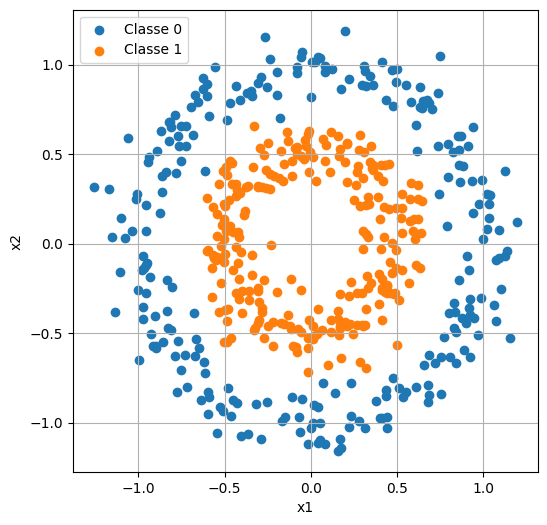

In [ ]:
# Création du dataset
#X, y = make_blobs(n_samples=500, centers=[[-1, -1], [1, 1]], cluster_std=0.5, random_state=0)
#X, y = make_moons(n_samples=500, noise=0.1, random_state=0)
X, y = make_circles(n_samples=500, noise=0.1, factor=0.5, random_state=0)

print(f'{X.shape=}')
print(f'{y.shape=}')

# Visualisation du dataset
plt.figure(figsize=(6, 6))
plt.scatter(X[:, 0][y == 0], X[:, 1][y == 0], label='Classe 0')
plt.scatter(X[:, 0][y == 1], X[:, 1][y == 1], label='Classe 1')
plt.xlabel('x1'); plt.ylabel('x2')
plt.legend(); plt.grid()

Les variables `X` et `y` sont ici des tableaux multidimensionnels NumPy.
Il faut convertir les données en tenseurs, le format équivalent en PyTorch.

In [ ]:
# Convertir les variables NumPy `X` et `y` en tenseurs PyTorch
X_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.float32).unsqueeze(1)
print(X_tensor.shape)
print(y_tensor.shape)

torch.Size([500, 2])
torch.Size([500, 1])


## 2. Définition du modèle

Nous allons mettre en place réseau de neurones composé d'un seul neurone. Pour cela, il existe différentes manières de faire en PyTorch.

In [ ]:
# Méthode 1 : création directe d'un modèle séquentiel
model1 = nn.Sequential(
    nn.Linear(in_features=2, out_features=1, bias=True)
)

In [ ]:
# Méthode 2 : définition d'une classe personnalisée
class Perceptron(nn.Module):
    def __init__(self):
        super().__init__()
        self.neuron = nn.Linear(in_features=2, out_features=1, bias=True)

    def forward(self, x):
        y_pred = self.neuron(x)
        return y_pred

model2 = Perceptron()

Dans les deux cas, le modèle a été initialisé avec des paramètres aléatoires, auxquels nous pouvons facilement accéder :

In [ ]:
# model1
m1w, m1b = model1[0].weight, model1[0].bias
print(m1w)
print(m1b)
# model2
m2w, m2b = model2.neuron.weight, model2.neuron.bias
print(m2w)
print(m2b)

Parameter containing:
tensor([[-0.5417, -0.1589]], requires_grad=True)
Parameter containing:
tensor([-0.6701], requires_grad=True)
Parameter containing:
tensor([[ 0.1130, -0.1430]], requires_grad=True)
Parameter containing:
tensor([0.4754], requires_grad=True)


Pour utiliser le modèle, il suffit de l'appeler avec des données passées en paramètre. Pour l'instant, le modèle n'est pas entraîné, donc les valeurs de sortie n'ont pas de sens.

In [ ]:
# Appel du modèle sur les 5 premiers points du dataset
y_pred = model1(X_tensor[:5])
print(y_pred)
y_pred_manual = X_tensor[:5] @ m1w.T + m1b
print(y_pred_manual)

tensor([[-0.4141],
        [-0.8457],
        [-0.9414],
        [-0.6276],
        [-0.7325]], grad_fn=<AddmmBackward0>)
tensor([[-0.4141],
        [-0.8457],
        [-0.9414],
        [-0.6276],
        [-0.7325]], grad_fn=<AddBackward0>)


## 3. Entraînement du modèle

Nous allons mettre en place la boucle d'apprentissage.

Pour un certain nombre d'itérations, aussi appelées *epochs* (= une passe complète sur le dataset), il faut :
- Passer les données du dataset dans le modèle afin d'obtenir ses prédictions
- Calculer la différence entre les prédictions et les vraies valeurs de classe, grâce à la *loss function*
- Mettre à jour les paramètres du modèle par descente de gradient

Une fois cette boucle terminée, les paramètres sont fixés et le modèle peut être utilisé pour faire des prédictions.

[epoch 000] loss = 0.3195
[epoch 005] loss = 0.3145
[epoch 010] loss = 0.3100
[epoch 015] loss = 0.3058
[epoch 020] loss = 0.3019
[epoch 025] loss = 0.2984
[epoch 030] loss = 0.2951
[epoch 035] loss = 0.2920
[epoch 040] loss = 0.2892
[epoch 045] loss = 0.2866
[epoch 000] loss = 0.5264
[epoch 005] loss = 0.3452
[epoch 010] loss = 0.2938
[epoch 015] loss = 0.2719
[epoch 020] loss = 0.2611
[epoch 025] loss = 0.2557
[epoch 030] loss = 0.2529
[epoch 035] loss = 0.2515
[epoch 040] loss = 0.2507
[epoch 045] loss = 0.2504
[epoch 000] loss = 0.4132
[epoch 005] loss = 0.2551
[epoch 010] loss = 0.2510
[epoch 015] loss = 0.2502
[epoch 020] loss = 0.2500
[epoch 025] loss = 0.2500
[epoch 030] loss = 0.2500
[epoch 035] loss = 0.2500
[epoch 040] loss = 0.2500
[epoch 045] loss = 0.2500
[epoch 000] loss = 0.3946
[epoch 005] loss = 0.2527
[epoch 010] loss = 0.2503
[epoch 015] loss = 0.2500
[epoch 020] loss = 0.2500
[epoch 025] loss = 0.2500
[epoch 030] loss = 0.2500
[epoch 035] loss = 0.2500
[epoch 040] 

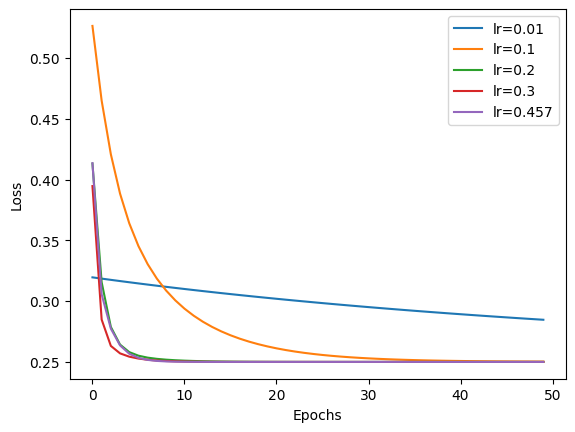

In [ ]:
n_epochs = 50
loss_fn = nn.MSELoss()
lr_values = [0.01, 0.1, 0.2, 0.3, 0.457]

def train(model, X, y, n_epochs, loss_fn, optimizer):
    loss_history = []
    for epoch in range(n_epochs):
        y_pred = model(X)
        loss = loss_fn(y_pred, y)
        loss_history.append(loss.item())

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if epoch % 5 == 0:
            print(f"[epoch {epoch:03d}] loss = {loss.item():.4f}")
    return loss_history

all_histories = {}
for lr in lr_values:
    # print(f"\n--- lr = {lr} ---")
    model = Perceptron()
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)
    all_histories[lr] = train(model, X_tensor, y_tensor, n_epochs, loss_fn, optimizer)

for lr, history in all_histories.items():
    plt.plot(history, label=f"lr={lr}")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

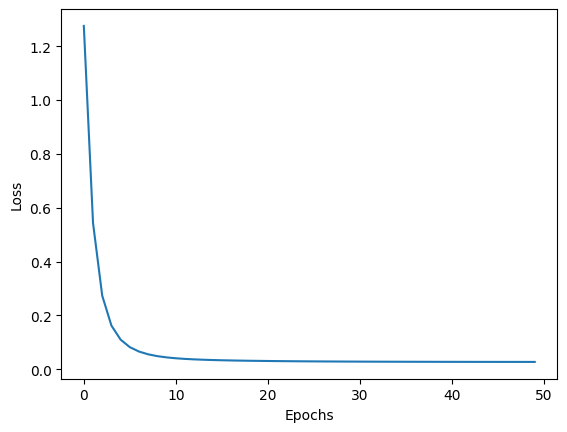

In [ ]:
# Affichage de la loss
plt.plot(loss_history)
plt.xlabel("Epochs"); plt.ylabel("Loss")
plt.show()

## 4. Visualisation des résultats

Le modèle entraîné définit une frontière de décision entre les deux classes.

[epoch 000] loss = 1.1881
[epoch 005] loss = 0.3905
[epoch 010] loss = 0.2853
[epoch 015] loss = 0.2640
[epoch 020] loss = 0.2567
[epoch 025] loss = 0.2533
[epoch 030] loss = 0.2517
[epoch 035] loss = 0.2508
[epoch 040] loss = 0.2504
[epoch 045] loss = 0.2502


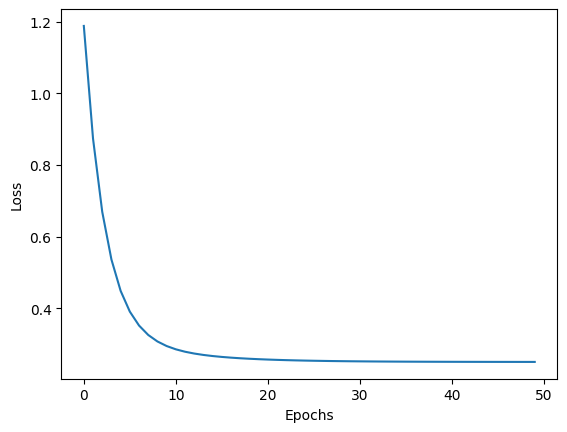

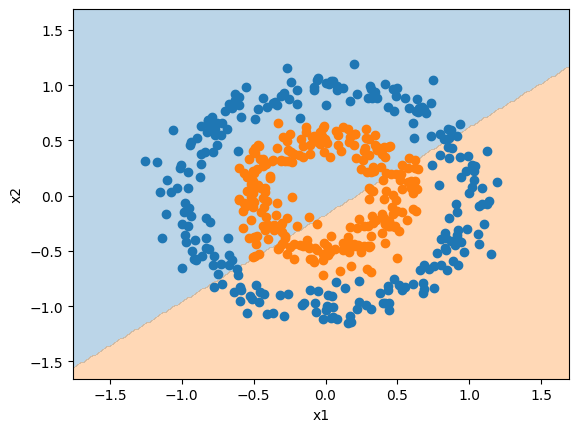

In [ ]:
n_epochs = 50
loss_fn = nn.MSELoss()

def train(model, X, y, n_epochs, loss_fn, optimizer):
    loss_history = []
    for epoch in range(n_epochs):
        y_pred = model(X)
        loss = loss_fn(y_pred, y)
        loss_history.append(loss.item())

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if epoch % 5 == 0:
            print(f"[epoch {epoch:03d}] loss = {loss.item():.4f}")
    return loss_history

# print(f"\n--- lr = {lr} ---")
model = Perceptron()
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)
history = train(model, X_tensor, y_tensor, n_epochs, loss_fn, optimizer)

plt.plot(history)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()



def plot_decision_boundary(model, X, y):
    # Définition d'une grille de points
    x_min, x_max = X[:, 0].min() - .5, X[:, 0].max() + .5
    y_min, y_max = X[:, 1].min() - .5, X[:, 1].max() + .5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))
    grid = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)
    # Prédiction du modèle pour l'ensemble de la grille et seuillage
    with torch.no_grad():
        y_pred = model(grid).reshape(xx.shape)
        y_pred = (y_pred >= 0.5)
    # Affichage de la frontière et du dataset
    plt.contourf(xx, yy, y_pred, alpha=0.3, levels=1, colors=['C0', 'C1'])
    plt.scatter(X[:, 0][y == 0], X[:, 1][y == 0], label='Classe 0')
    plt.scatter(X[:, 0][y == 1], X[:, 1][y == 1], label='Classe 1')
    w2, w1 = model.neuron.weight[0].detach().numpy()
    plt.xlabel("x1"); plt.ylabel("x2")
    plt.show()

plot_decision_boundary(model2, X, y)

## 5. Influence du *learning rate*

Le *learning rate* contrôle la vitesse d’apprentissage du modèle. Une valeur trop faible ralentit la convergence, tandis qu’une valeur trop élevée peut empêcher l’apprentissage.

Reprendre le code précédent et mettre en place une expérience pour observer l’impact du *learning rate* sur l’entraînement. Vous pouvez, par exemple, tracer l’évolution de la loss pour différentes valeurs de *learning rate*.

In [ ]:
# YOUR CODE HERE
raise NotImplementedError()

## 6. Limites de la classification linéaire

Reprendre le code du TP et l'appliquer sur des datasets synthétiques générés par les fonctions `make_moons` ou `make_circles`.

Que constatez-vous ? Le modèle arrive-t-il à bien séparer les classes ? Expliquer pourquoi les performances se dégradent.

In [ ]:
# YOUR CODE HERE
raise NotImplementedError()

YOUR ANSWER HERE